/home/yasir.ech-chammakhy/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Results saved to ner_model_results.csv
Found results for 20 model-dataset combinations

Overall Results:


,dataset,model,f1_score,accuracy
0,APTNER,bert-base-cased,78.14%,95.12%
1,APTNER,roberta-base,78.08%,94.46%
2,APTNER,securebert,78.28%,94.66%
3,APTNER,darkbert,78.73%,94.94%
4,APTNER,cysecbert,79.19%,95.34%
5,CyNER,bert-base-cased,86.91%,98.29%
6,CyNER,roberta-base,84.00%,97.75%
7,CyNER,securebert,85.23%,98.09%
8,CyNER,darkbert,86.55%,98.26%
9,CyNER,cysecbert,85.91%,98.20%



F1 Score Comparison:


dataset,APTNER,Attacker,CyNER,DNRTI
model,,,,
bert-base-cased,0.781365,0.734030,0.869071,0.868805
cysecbert,0.791860,0.731875,0.859095,0.869558
darkbert,0.787291,0.719212,0.865543,0.870752
roberta-base,0.780827,0.712687,0.839959,0.860040
securebert,0.782763,0.730142,0.852326,0.867990


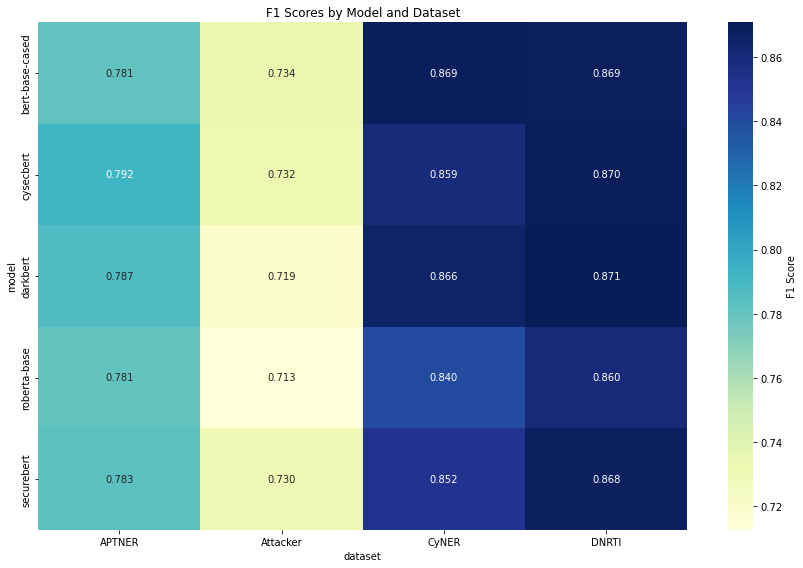

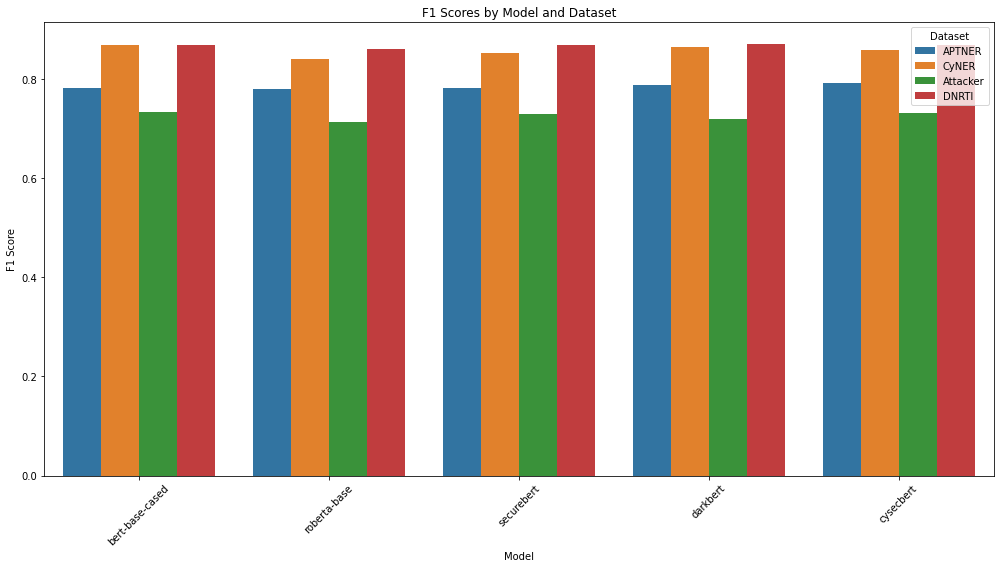


Best Model for Each Dataset:


,dataset,model,f1_score
4,APTNER,cysecbert,0.791860
10,Attacker,bert-base-cased,0.734030
5,CyNER,bert-base-cased,0.869071
18,DNRTI,darkbert,0.870752



Entity-Specific Performance:


,Entity Type,Average F1 Score
4,B-IPv4-Addr,0.918503
6,B-Location,0.880394
10,B-Threat-Actor,0.860942
9,B-Software,0.852167
2,B-Email-Addr,0.845275
7,B-Malware,0.832211
13,B-Vulnerability,0.828011
1,B-Domain-Name,0.821564
5,B-Identity,0.821232
39,I-Malware-Analysis,0.816104


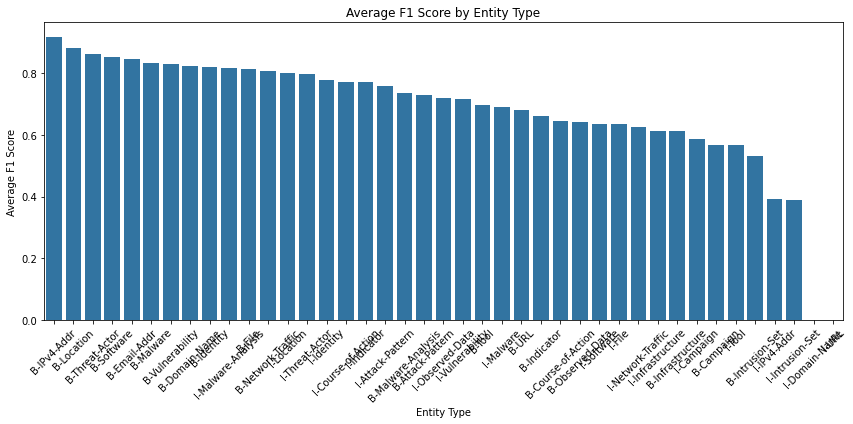

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Path to your output directory containing all the model results
base_output_dir = "/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs"

# Define datasets and models
datasets = ["APTNER", "CyNER", "Attacker", "DNRTI"]
models = ["bert-base-cased", "roberta-base", "securebert", "darkbert", "cysecbert"]

# Function to extract metrics from test_results.json
def extract_metrics(result_path):
    try:
        with open(result_path, 'r') as f:
            results = json.load(f)
            
        # Extract the overall metrics
        metrics = {
            'test_accuracy': results.get('test_accuracy', 0),
            'test_f1': results.get('test_f1', 0)
        }
        
        # Extract class-specific metrics if available
        class_metrics = results.get('class_metrics', {})
        entity_f1_scores = {}
        
        for entity_type, entity_metrics in class_metrics.items():
            # Skip special tokens or non-entity labels
            if entity_type in ['O', '[CLS]', '[SEP]', 'X']:
                continue
                
            entity_f1_scores[entity_type] = entity_metrics.get('f1', 0)
            
        metrics['entity_f1_scores'] = entity_f1_scores
        
        return metrics
    except Exception as e:
        print(f"Error extracting metrics from {result_path}: {e}")
        return None

# Collect all results
all_results = []

for dataset in datasets:
    for model in models:
        # Format directory name based on your output structure
        model_dir = f"{dataset}_{model.replace('/', '_')}"
        result_path = os.path.join(base_output_dir, model_dir, "test_results.json")
        
        if os.path.exists(result_path):
            metrics = extract_metrics(result_path)
            
            if metrics:
                result_entry = {
                    'dataset': dataset,
                    'model': model,
                    'f1_score': metrics['test_f1'],
                    'accuracy': metrics['test_accuracy']
                }
                
                # Add entity-specific F1 scores
                for entity_type, f1_score in metrics.get('entity_f1_scores', {}).items():
                    result_entry[f'{entity_type}_f1'] = f1_score
                
                all_results.append(result_entry)
        else:
            print(f"Results file not found: {result_path}")

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(all_results)

# Save results to CSV
results_df.to_csv('ner_model_results.csv', index=False)
print(f"Results saved to ner_model_results.csv")
print(f"Found results for {len(results_df)} model-dataset combinations")

# Display overall results table
if not results_df.empty:
    # Format F1 and accuracy as percentages
    display_df = results_df.copy()
    display_df['f1_score'] = display_df['f1_score'].apply(lambda x: f"{x*100:.2f}%")
    display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x*100:.2f}%")
    
    print("\nOverall Results:")
    display(display_df[['dataset', 'model', 'f1_score', 'accuracy']])
    
    # Create pivot table for F1 scores
    f1_pivot = results_df.pivot(index='model', columns='dataset', values='f1_score')
    
    print("\nF1 Score Comparison:")
    display(f1_pivot)
    
    # Visualize results
    plt.figure(figsize=(12, 8))
    ax = sns.heatmap(f1_pivot, annot=True, cmap="YlGnBu", fmt=".3f", cbar_kws={'label': 'F1 Score'})
    plt.title('F1 Scores by Model and Dataset')
    plt.tight_layout()
    plt.savefig('f1_score_heatmap.png')
    plt.show()
    
    # Bar chart comparison
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(x='model', y='f1_score', hue='dataset', data=results_df)
    plt.title('F1 Scores by Model and Dataset')
    plt.xlabel('Model')
    plt.ylabel('F1 Score')
    plt.xticks(rotation=45)
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.savefig('f1_score_barplot.png')
    plt.show()
    
    # Find best model for each dataset
    best_models = results_df.loc[results_df.groupby('dataset')['f1_score'].idxmax()]
    print("\nBest Model for Each Dataset:")
    display(best_models[['dataset', 'model', 'f1_score']])
    
    # Entity-specific analysis if available
    entity_columns = [col for col in results_df.columns if col.endswith('_f1') and col != 'f1_score']
    
    if entity_columns:
        print("\nEntity-Specific Performance:")
        
        # Get average F1 score for each entity type across models and datasets
        entity_performance = {}
        for col in entity_columns:
            entity_type = col.replace('_f1', '')
            avg_f1 = results_df[col].mean()
            entity_performance[entity_type] = avg_f1
        
        entity_df = pd.DataFrame(list(entity_performance.items()), columns=['Entity Type', 'Average F1 Score'])
        entity_df = entity_df.sort_values('Average F1 Score', ascending=False)
        
        display(entity_df)
        
        # Plot entity performance
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(x='Entity Type', y='Average F1 Score', data=entity_df)
        plt.title('Average F1 Score by Entity Type')
        plt.xlabel('Entity Type')
        plt.ylabel('Average F1 Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('entity_f1_scores.png')
        plt.show()
else:
    print("No results found. Check the output directory path.")

In [4]:
import os
import json
import pandas as pd
import numpy as np

# Path to your output directory containing all the model results
base_output_dir = "/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs"

# Define datasets and models
datasets = ["APTNER", "CyNER", "Attacker", "DNRTI"]
models = ["bert-base-cased", "roberta-base", "securebert", "darkbert", "cysecbert"]

# Dictionary to map model names for display
model_display = {
    "bert-base-cased": "BERT-base",
    "roberta-base": "RoBERTa",
    "securebert": "SecureBERT",
    "darkbert": "DarkBERT", 
    "cysecbert": "CySecBERT"
}

# Create an empty list to hold all results
results = []

# Extract metrics from each test_results.json file
for dataset in datasets:
    for model in models:
        model_dir = f"{dataset}_{model.replace('/', '_')}"
        result_path = os.path.join(base_output_dir, model_dir, "test_results.json")
        
        if os.path.exists(result_path):
            try:
                with open(result_path, 'r') as f:
                    data = json.load(f)
                
                # Extract accuracy and F1 score
                accuracy = data.get('test_accuracy', 0)
                f1 = data.get('test_f1', 0)
                
                # Calculate weighted precision and recall from class metrics
                class_metrics = data.get('class_metrics', {})
                
                # Initialize variables for weighted calculation
                total_precision_sum = 0
                total_recall_sum = 0
                total_support = 0
                
                # Process each entity type
                for entity_type, metrics in class_metrics.items():
                    # Skip non-entity labels (O, X, [CLS], [SEP])
                    if entity_type in ['O', 'X', '[CLS]', '[SEP]']:
                        continue
                    
                    # Get metrics for this entity
                    precision = metrics.get('precision', 0)
                    recall = metrics.get('recall', 0)
                    support = metrics.get('support', 0)
                    
                    # Handle NaN values (convert to 0 for calculation)
                    if isinstance(precision, float) and np.isnan(precision):
                        precision = 0
                    
                    # Add to weighted sums
                    total_precision_sum += precision * support
                    total_recall_sum += recall * support
                    total_support += support
                
                # Calculate weighted averages
                if total_support > 0:
                    weighted_precision = total_precision_sum / total_support
                    weighted_recall = total_recall_sum / total_support
                else:
                    weighted_precision = 0
                    weighted_recall = 0
                
                # Add results to list
                results.append({
                    'Dataset': dataset,
                    'Model': model_display.get(model, model),
                    'Accuracy': accuracy,
                    'F1': f1,
                    'Precision': weighted_precision,
                    'Recall': weighted_recall
                })
                
            except Exception as e:
                print(f"Error processing {result_path}: {e}")
        else:
            print(f"File not found: {result_path}")

# Create DataFrame
results_df = pd.DataFrame(results)

# Format numbers to 4 decimal places
for col in ['Accuracy', 'F1', 'Precision', 'Recall']:
    results_df[col] = results_df[col].map('{:.4f}'.format)

# Sort by Dataset and Model
results_df = results_df.sort_values(['Dataset', 'Model'])

# Display the table
print(results_df)

     Dataset       Model Accuracy      F1 Precision  Recall
0     APTNER   BERT-base   0.9512  0.7814    0.8031  0.7585
4     APTNER   CySecBERT   0.9534  0.7919    0.8109  0.7698
3     APTNER    DarkBERT   0.9494  0.7873    0.7935  0.7794
1     APTNER     RoBERTa   0.9446  0.7808    0.7876  0.7705
2     APTNER  SecureBERT   0.9466  0.7828    0.7770  0.7886
10  Attacker   BERT-base   0.8264  0.7340    0.7624  0.7083
14  Attacker   CySecBERT   0.8199  0.7319    0.7590  0.7303
13  Attacker    DarkBERT   0.8164  0.7192    0.7611  0.6913
11  Attacker     RoBERTa   0.8131  0.7127    0.7391  0.7034
12  Attacker  SecureBERT   0.8181  0.7301    0.7340  0.7343
5      CyNER   BERT-base   0.9829  0.8691    0.8745  0.8656
9      CyNER   CySecBERT   0.9820  0.8591    0.8451  0.8782
8      CyNER    DarkBERT   0.9826  0.8655    0.8658  0.8716
6      CyNER     RoBERTa   0.9775  0.8400    0.8619  0.8224
7      CyNER  SecureBERT   0.9809  0.8523    0.8630  0.8410
15     DNRTI   BERT-base   0.9558  0.868

In [13]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set a font that is typically available across systems
rcParams['font.family'] = 'DejaVu Serif'  # You can also use 'Arial' or 'Liberation Serif' if preferred


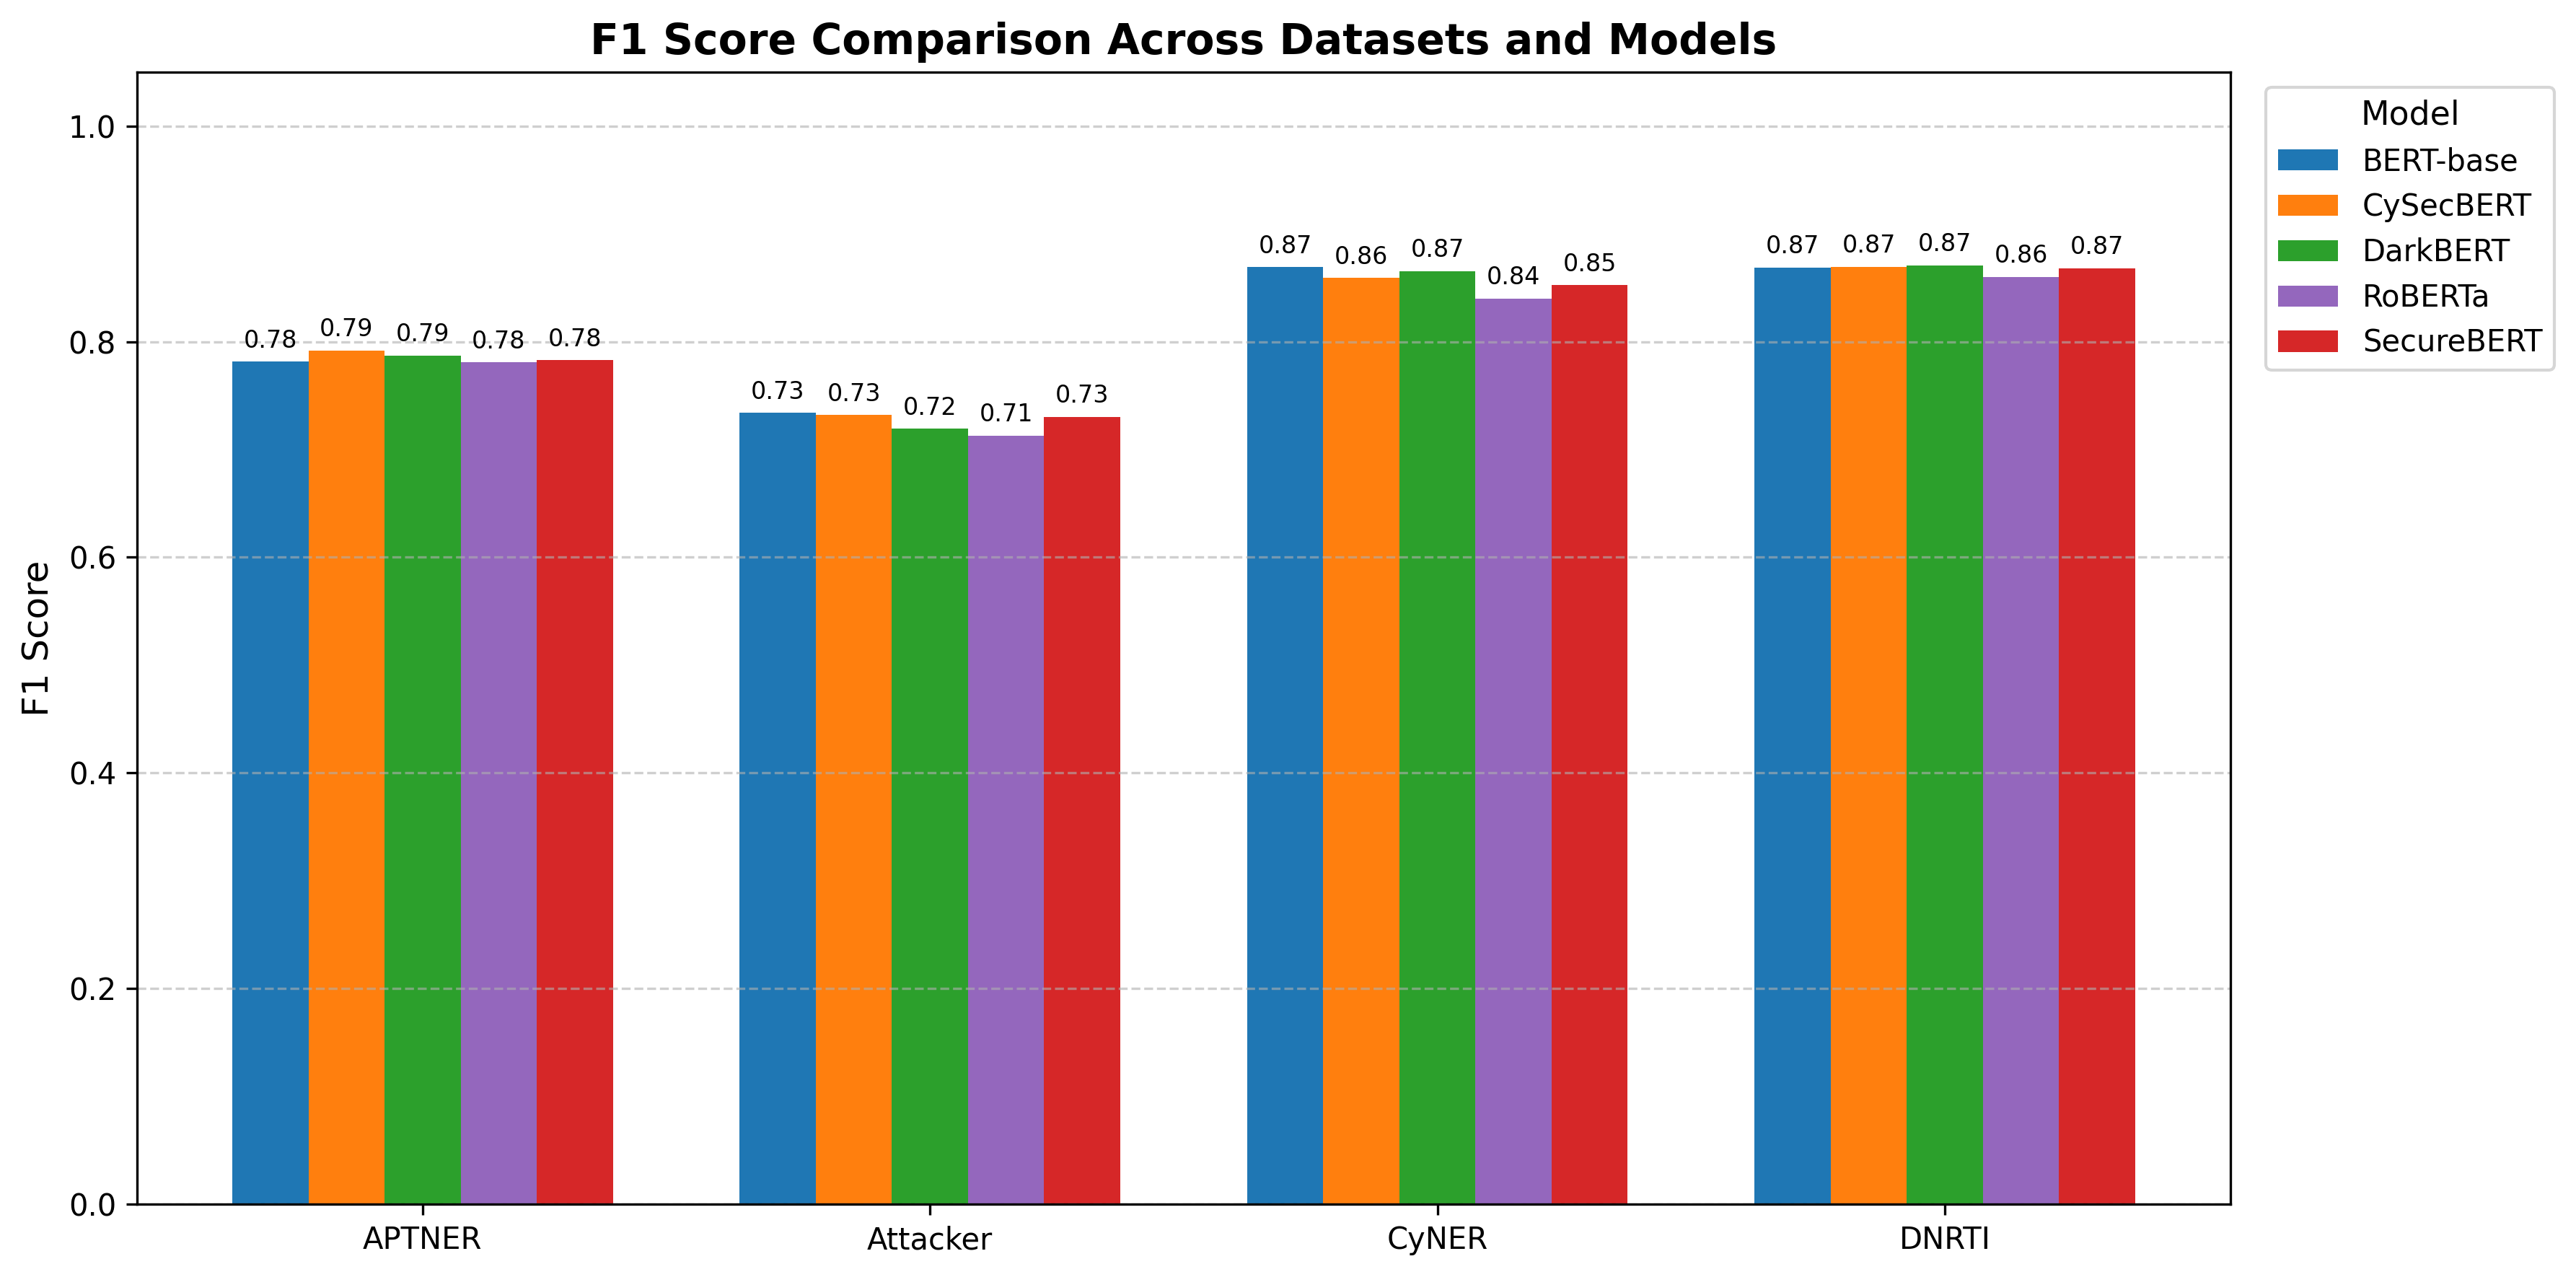

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Convert F1 column to float for plotting
results_df_numeric = results_df.copy()
results_df_numeric['F1'] = results_df_numeric['F1'].astype(float)

# Unique datasets and models
datasets = results_df_numeric['Dataset'].unique()
models = results_df_numeric['Model'].unique()

x = np.arange(len(datasets))
width = 0.15

# Colorblind-friendly colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']

# Create plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

for i, model in enumerate(models):
    model_scores = [
        results_df_numeric[
            (results_df_numeric['Model'] == model) & 
            (results_df_numeric['Dataset'] == dataset)
        ]['F1'].values[0]
        for dataset in datasets
    ]
    
    positions = x + i * width
    bars = ax.bar(positions, model_scores, width, label=model, color=colors[i])
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# Axis labels and title
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("F1 Score Comparison Across Datasets and Models", fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(datasets, fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Move legend outside the plot to the right
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
# Optional export
# plt.savefig("f1_score_legend_outside.png", bbox_inches='tight', dpi=300)

plt.show()


<ipython-input-8-b53b1f2d7b82>:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


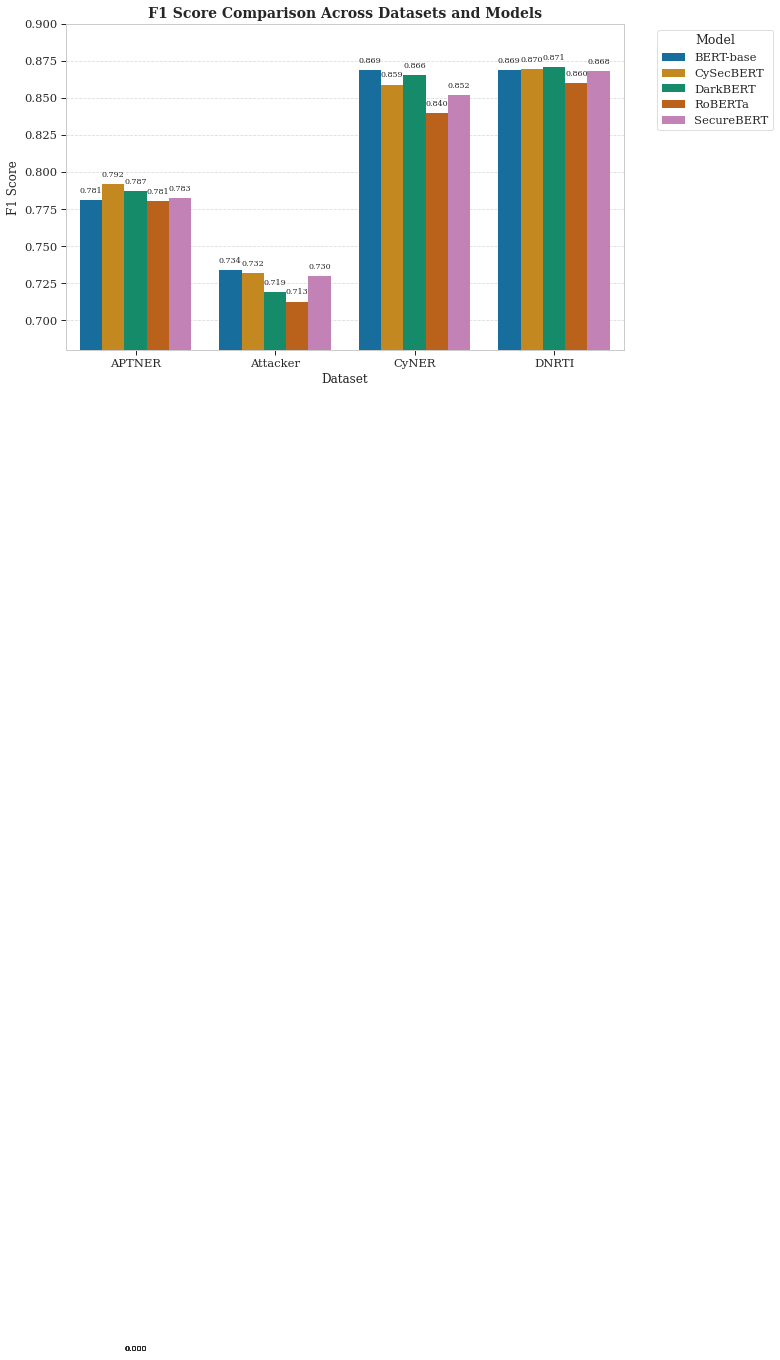

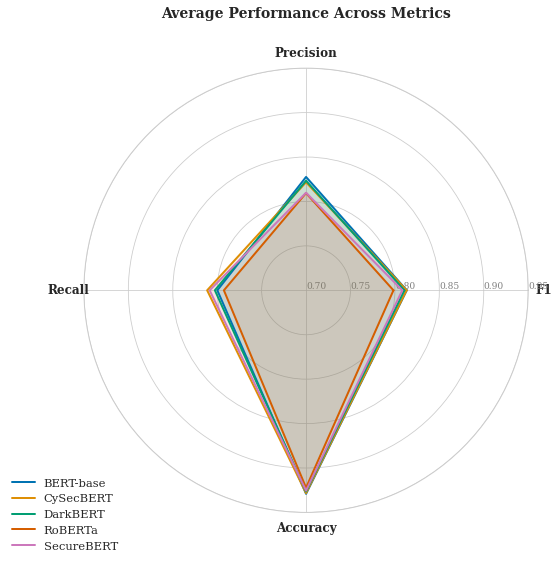

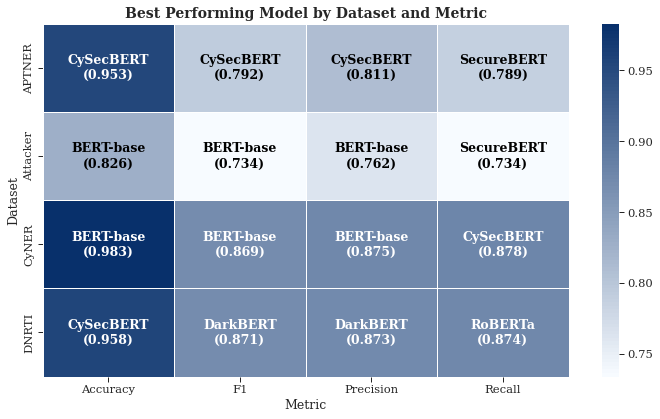

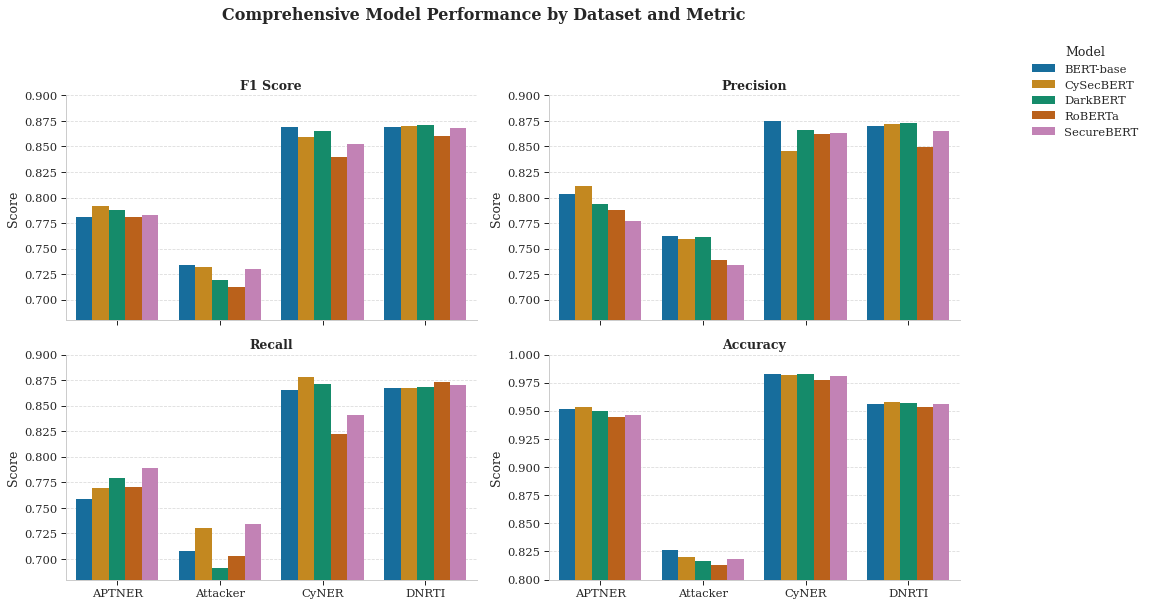

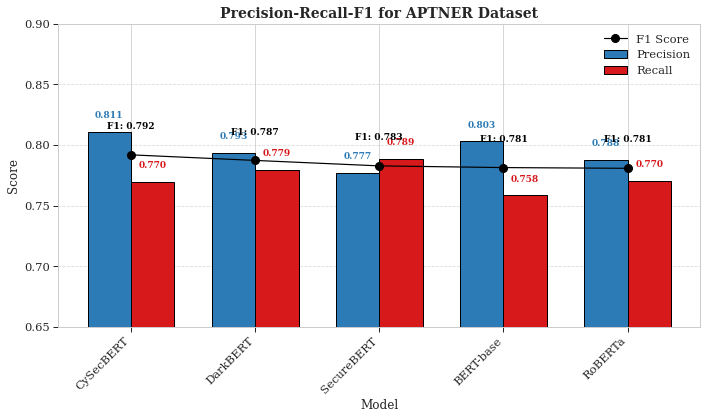

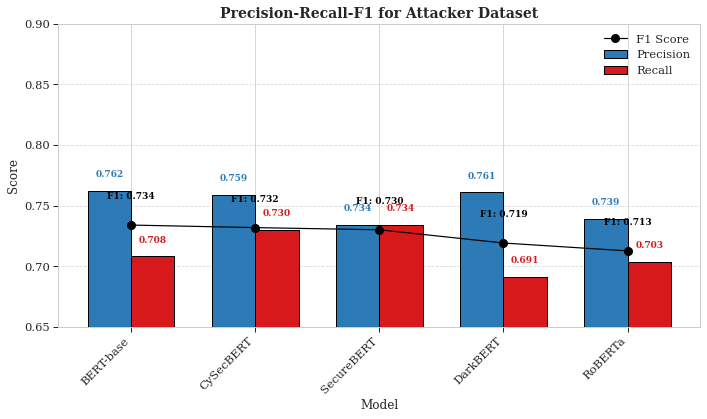

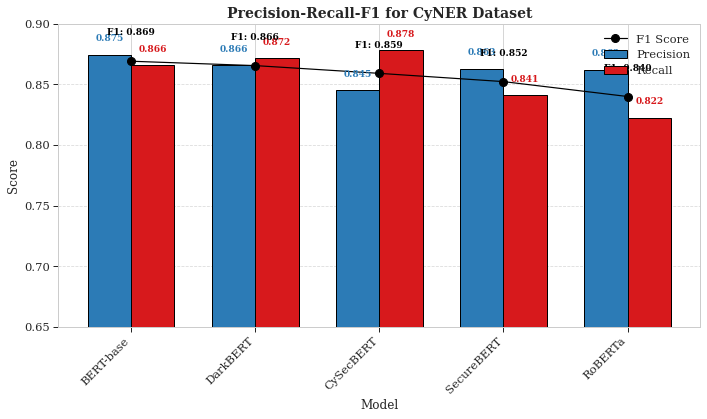

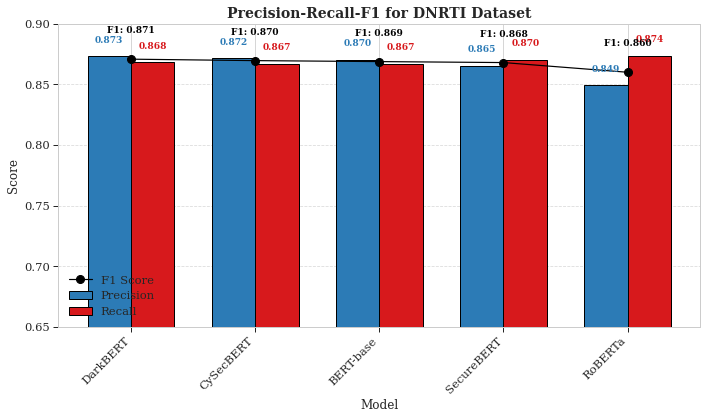

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# Set publication-quality settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Create the dataset from the results table
data = {
    'Dataset': ['APTNER', 'APTNER', 'APTNER', 'APTNER', 'APTNER', 
                'Attacker', 'Attacker', 'Attacker', 'Attacker', 'Attacker',
                'CyNER', 'CyNER', 'CyNER', 'CyNER', 'CyNER',
                'DNRTI', 'DNRTI', 'DNRTI', 'DNRTI', 'DNRTI'],
    'Model': ['BERT-base', 'CySecBERT', 'DarkBERT', 'RoBERTa', 'SecureBERT',
              'BERT-base', 'CySecBERT', 'DarkBERT', 'RoBERTa', 'SecureBERT',
              'BERT-base', 'CySecBERT', 'DarkBERT', 'RoBERTa', 'SecureBERT',
              'BERT-base', 'CySecBERT', 'DarkBERT', 'RoBERTa', 'SecureBERT'],
    'Accuracy': [0.9512, 0.9534, 0.9494, 0.9446, 0.9466,
                 0.8264, 0.8199, 0.8164, 0.8131, 0.8181,
                 0.9829, 0.9820, 0.9826, 0.9775, 0.9809,
                 0.9558, 0.9580, 0.9572, 0.9537, 0.9562],
    'F1': [0.7814, 0.7919, 0.7873, 0.7808, 0.7828,
           0.7340, 0.7319, 0.7192, 0.7127, 0.7301,
           0.8691, 0.8591, 0.8655, 0.8400, 0.8523,
           0.8688, 0.8696, 0.8708, 0.8600, 0.8680],
    'Precision': [0.8031, 0.8109, 0.7935, 0.7876, 0.7770,
                  0.7624, 0.7590, 0.7611, 0.7391, 0.7340,
                  0.8745, 0.8451, 0.8658, 0.8619, 0.8630,
                  0.8704, 0.8715, 0.8731, 0.8493, 0.8654],
    'Recall': [0.7585, 0.7698, 0.7794, 0.7705, 0.7886,
               0.7083, 0.7303, 0.6913, 0.7034, 0.7343,
               0.8656, 0.8782, 0.8716, 0.8224, 0.8410,
               0.8670, 0.8670, 0.8682, 0.8736, 0.8701]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Define professional color palette - colorblind-friendly for academic publications
colors = ["#0173B2", "#DE8F05", "#029E73", "#D55E00", "#CC78BC"]
model_colors = {model: color for model, color in zip(df['Model'].unique(), colors)}

# Function to show plots (for interactive environments)
def show_plot():
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# FIGURE 1: F1 SCORE COMPARISON ACROSS DATASETS AND MODELS
# ----------------------------------------------------------------------------
def create_f1_comparison():
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Dataset', y='F1', hue='Model', data=df, palette=colors, errorbar=None)

    plt.title('F1 Score Comparison Across Datasets and Models', fontweight='bold', fontsize=14)
    plt.xlabel('Dataset', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.ylim(0.68, 0.90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of bars
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', fontsize=8)

    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    show_plot()

# ----------------------------------------------------------------------------
# FIGURE 2: RADAR CHART - MODEL COMPARISON ACROSS METRICS
# ----------------------------------------------------------------------------
def create_radar_chart():
    # Calculate average performance for each model
    model_avg = df.groupby('Model')[['F1', 'Precision', 'Recall', 'Accuracy']].mean().reset_index()

    # Set up variables for radar chart
    categories = ['F1', 'Precision', 'Recall', 'Accuracy']
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot each model
    for i, model in enumerate(model_avg['Model']):
        values = model_avg.loc[model_avg['Model'] == model, categories].values.flatten().tolist()
        values += values[:1]  # Close the loop
        
        ax.plot(angles, values, linewidth=2, linestyle='-', label=model, color=model_colors[model])
        ax.fill(angles, values, color=model_colors[model], alpha=0.1)

    # Set category labels
    plt.xticks(angles[:-1], categories, fontsize=12, fontweight='bold')

    # Add radial labels with formatting
    ax.set_rlabel_position(0)
    plt.yticks([0.7, 0.75, 0.8, 0.85, 0.9, 0.95], 
            ["0.70", "0.75", "0.80", "0.85", "0.90", "0.95"], 
            color="grey", size=9)
    plt.ylim(0.7, 0.95)

    # Add legend with proper formatting
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Average Performance Across Metrics', size=14, fontweight='bold', y=1.1)
    show_plot()

# ----------------------------------------------------------------------------
# FIGURE 3: HEATMAP - BEST MODEL FOR EACH DATASET AND METRIC
# ----------------------------------------------------------------------------
def create_best_model_heatmap():
    # Identify best model for each dataset and metric
    best_models = {}
    for metric in ['F1', 'Precision', 'Recall', 'Accuracy']:
        best_models[metric] = {}
        for dataset in df['Dataset'].unique():
            subset = df[df['Dataset'] == dataset]
            idx = subset[metric].idxmax()
            best_models[metric][dataset] = (subset.loc[idx, 'Model'], subset.loc[idx, metric])

    # Create heatmap data
    heatmap_data = []
    for dataset in df['Dataset'].unique():
        for metric in ['F1', 'Precision', 'Recall', 'Accuracy']:
            model, value = best_models[metric][dataset]
            heatmap_data.append({
                'Dataset': dataset, 
                'Metric': metric, 
                'Best Model': model, 
                'Value': value
            })

    heatmap_df = pd.DataFrame(heatmap_data)
    pivot_table = pd.pivot_table(heatmap_df, values='Value', index='Dataset', columns='Metric')

    # Create custom colormap
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#f7fbff', '#08306b'], N=100)

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(pivot_table, annot=False, cmap=cmap, linewidths=.5)

    # Add annotations with model name and value
    for i, dataset in enumerate(pivot_table.index):
        for j, metric in enumerate(pivot_table.columns):
            model, value = best_models[metric][dataset]
            text_color = 'white' if value > 0.85 else 'black'
            ax.text(j + 0.5, i + 0.5, f"{model}\n({value:.3f})", 
                    ha='center', va='center', color=text_color, fontweight='bold')

    plt.title('Best Performing Model by Dataset and Metric', fontsize=14, fontweight='bold')
    show_plot()

# ----------------------------------------------------------------------------
# FIGURE 4: PRECISION-RECALL-F1 COMPARISON BY DATASET
# ----------------------------------------------------------------------------
def create_pr_f1_comparison(dataset_name=None):
    # If dataset_name is provided, create for that dataset only
    # Otherwise, create for all datasets
    datasets_to_process = [dataset_name] if dataset_name else df['Dataset'].unique()
    
    for dataset in datasets_to_process:
        dataset_df = df[df['Dataset'] == dataset].sort_values('F1', ascending=False)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Bar width and positions
        n_models = len(dataset_df)
        width = 0.35
        x = np.arange(n_models)
        
        # Plot bars
        prec_bars = ax.bar(x - width/2, dataset_df['Precision'], width, label='Precision', 
                          color='#2c7bb6', edgecolor='black', linewidth=1)
        recall_bars = ax.bar(x + width/2, dataset_df['Recall'], width, label='Recall', 
                            color='#d7191c', edgecolor='black', linewidth=1)
        
        # Add F1 markers
        ax.plot(x, dataset_df['F1'], 'ko-', markersize=8, label='F1 Score')
        
        # Customize plot
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title(f'Precision-Recall-F1 for {dataset} Dataset', fontweight='bold', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(dataset_df['Model'], rotation=45, ha='right')
        ax.set_ylim(0.65, 0.9)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.legend()
        
        # Add value labels
        for i, model in enumerate(dataset_df['Model']):
            ax.text(i - width/2, dataset_df.iloc[i]['Precision'] + 0.01, f"{dataset_df.iloc[i]['Precision']:.3f}", 
                    ha='center', va='bottom', color='#2c7bb6', fontweight='bold', fontsize=9)
            ax.text(i + width/2, dataset_df.iloc[i]['Recall'] + 0.01, f"{dataset_df.iloc[i]['Recall']:.3f}", 
                    ha='center', va='bottom', color='#d7191c', fontweight='bold', fontsize=9)
            ax.text(i, dataset_df.iloc[i]['F1'] + 0.02, f"F1: {dataset_df.iloc[i]['F1']:.3f}", 
                    ha='center', va='bottom', color='black', fontweight='bold', fontsize=9)
        
        show_plot()

# ----------------------------------------------------------------------------
# FIGURE 5: COMPREHENSIVE COMPARISON - ALL METRICS
# ----------------------------------------------------------------------------
def create_comprehensive_comparison():
    # Prepare data in long format for facet plotting
    long_df = pd.melt(df, id_vars=['Dataset', 'Model'], 
                      value_vars=['F1', 'Precision', 'Recall', 'Accuracy'],
                      var_name='Metric', value_name='Score')

    # Create custom FacetGrid for comparison
    g = sns.FacetGrid(long_df, col='Metric', col_wrap=2, height=4, aspect=1.5, 
                      sharex=True, sharey=False)

    # Map barplot to each facet
    g.map_dataframe(sns.barplot, x='Dataset', y='Score', hue='Model', 
                    palette=colors, errorbar=None)

    # Customize each facet
    for ax, title in zip(g.axes.flat, ['F1 Score', 'Precision', 'Recall', 'Accuracy']):
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Score')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Set appropriate y-axis limits based on the metric
        if title == 'Accuracy':
            ax.set_ylim(0.8, 1.0)
        else:
            ax.set_ylim(0.68, 0.9)

    # Add legend to the first subplot
    g.add_legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    g.fig.suptitle('Comprehensive Model Performance by Dataset and Metric', 
                   fontsize=16, fontweight='bold', y=1.05)
    show_plot()

# Call the visualization functions to generate each figure
# Comment/uncomment as needed
create_f1_comparison()
create_radar_chart()
create_best_model_heatmap()
create_comprehensive_comparison()

# Create PR-F1 comparison for each dataset
for dataset in df['Dataset'].unique():
    create_pr_f1_comparison(dataset)